<a href="https://colab.research.google.com/github/Dhanush7-tech/Deep-Learning-LAB/blob/main/Lab-4/DeepLearning_Lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1339s 8us/step


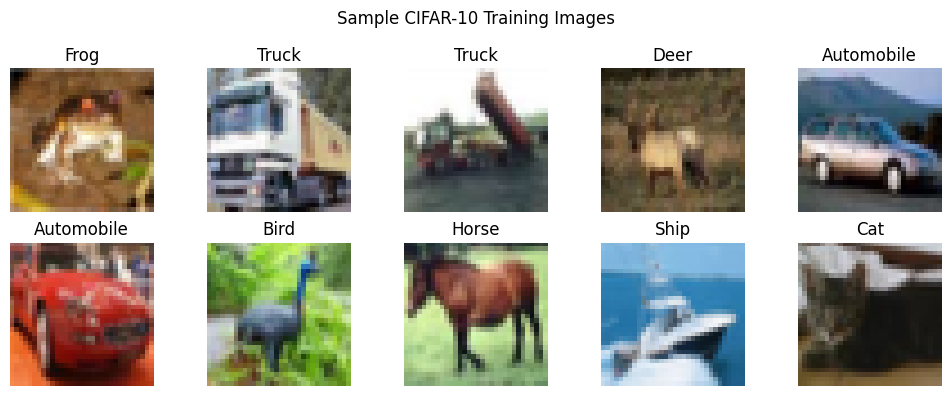

Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing images shape:  (10000, 32, 32, 3)
Testing labels shape:  (10000, 1)


In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Load the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# 2. Normalize pixel values to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Class names for CIFAR-10 (label indices 0-9)
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# 3. Display ten sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.suptitle("Sample CIFAR-10 Training Images")
plt.tight_layout()
plt.show()

# 4. Print dimensions of training and testing datasets
print(f"Training images shape: {x_train.shape}")   # (50000, 32, 32, 3)
print(f"Training labels shape: {y_train.shape}")   # (50000, 1)
print(f"Testing images shape:  {x_test.shape}")    # (10000, 32, 32, 3)
print(f"Testing labels shape:  {y_test.shape}")    # (10000, 1)

In [2]:
"""
Task 2: Transfer Learning
Using MobileNetV2 pretrained on ImageNet as the base model.

Steps:
1. Load pretrained ImageNet weights.
2. Remove the original classification layer (include_top=False).
3. Freeze the convolutional base.
4. Add a Global Average Pooling layer.
5. Add a Dense layer with ReLU activation.
6. Add the output layer with Softmax activation.
"""

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

NUM_CLASSES = 10
INPUT_SHAPE = (32, 32, 3)  # CIFAR-10 native image size

# 1 & 2. Load pretrained ImageNet weights, remove original classifier head
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,       # removes the original 1000-class classification layer
    input_shape=INPUT_SHAPE
)

# 3. Freeze the convolutional base
base_model.trainable = False

# 4, 5, 6. Build the new classification head
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),          # Global Average Pooling layer
    layers.Dense(128, activation="relu"),     # Dense layer with ReLU activation
    layers.Dense(NUM_CLASSES, activation="softmax")  # Output layer with Softmax
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

print(f"\nTrainable layers: {sum(1 for l in model.layers if l.trainable)}")
print(f"Total parameters: {model.count_params():,}")
print(f"Trainable parameters: {sum(tf.keras.backend.count_params(w) for w in model.trainable_weights):,}")

/tmp/ipykernel_478/2169818850.py:22: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Trainable layers: 3
Total parameters: 2,423,242
Trainable parameters: 165,258


In [3]:
"""
Task 3: Model Training

Optimizer      : Adam
Learning Rate  : 0.001
Batch Size     : 32
Epochs         : 15 (within the 10-20 range)
Loss Function  : Categorical Cross Entropy
Metric         : Accuracy
"""

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

NUM_CLASSES = 10
INPUT_SHAPE = (32, 32, 3)
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 0.001

# ---------------------------------------------------------------
# 1. Load and prepare data (Task 1)
# ---------------------------------------------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Categorical Cross Entropy requires one-hot encoded labels
y_train = to_categorical(y_train, NUM_CLASSES)
y_test = to_categorical(y_test, NUM_CLASSES)

# ---------------------------------------------------------------
# 2. Build the transfer learning model (Task 2)
# ---------------------------------------------------------------
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=INPUT_SHAPE
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

# ---------------------------------------------------------------
# 3. Compile with specified optimizer, loss, and metric
# ---------------------------------------------------------------
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ---------------------------------------------------------------
# 4. Train the model
# ---------------------------------------------------------------
history = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_test, y_test)
)

# ---------------------------------------------------------------
# 5. Save the trained model and training history
# ---------------------------------------------------------------
model.save("cifar10_transfer_model.keras")

import pickle
with open("training_history.pkl", "wb") as f:
    pickle.dump(history.history, f)

print("\nTraining complete. Model saved as 'cifar10_transfer_model.keras'.")
final_train_acc = history.history["accuracy"][-1]
final_val_acc = history.history["val_accuracy"][-1]
print(f"Final training accuracy:   {final_train_acc:.4f}")
print(f"Final validation accuracy: {final_val_acc:.4f}")

/tmp/ipykernel_478/2088286772.py:39: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 25ms/step - accuracy: 0.3042 - loss: 1.9281 - val_accuracy: 0.3233 - val_loss: 1.8654
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.3356 - loss: 1.8290 - val_accuracy: 0.3385 - val_loss: 1.8262
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 26ms/step - accuracy: 0.3504 - loss: 1.7892 - val_accuracy: 0.3482 - val_loss: 1.8131
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.3612 - loss: 1.7618 - val_accuracy: 0.3483 - val_loss: 1.8057
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 27ms/step - accuracy: 0.3686 - loss: 1.7397 - val_accuracy: 0.3509 - val_loss: 1.8001
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.3772 - loss: 1.7214 - val_accuracy: 0.3544 - val_loss: 1.7933
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.3802 - loss: 1.7048 - val_accuracy: 0.3546 - val_loss: 1.7955
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.3878 -

In [4]:
"""
Task 4: Fine Tuning

1. Unfreeze the last convolutional block of the base model.
2. Train for another 5-10 epochs.
3. Compare classification accuracy before and after fine-tuning.

NOTE: This script continues from Task 3 - it assumes `model`, `history`,
`x_train`, `y_train`, `x_test`, `y_test` already exist in the same session.
If running standalone, it reloads the saved model and re-prepares the data.
"""

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

NUM_CLASSES = 10
BATCH_SIZE = 32
FINE_TUNE_EPOCHS = 8          # within the 5-10 range
FINE_TUNE_LR = 1e-5           # lower LR for fine-tuning to avoid destroying pretrained features

# ---------------------------------------------------------------
# Reload model/data if running standalone (skip if continuing from Task 3)
# ---------------------------------------------------------------
try:
    model
    history
except NameError:
    model = tf.keras.models.load_model("cifar10_transfer_model.keras")

    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    x_train = x_train.astype("float32") / 255.0
    x_test = x_test.astype("float32") / 255.0
    y_train = to_categorical(y_train, NUM_CLASSES)
    y_test = to_categorical(y_test, NUM_CLASSES)

    import pickle
    with open("training_history.pkl", "rb") as f:
        history_dict = pickle.load(f)
else:
    history_dict = history.history

# ---------------------------------------------------------------
# 0. Record accuracy BEFORE fine-tuning (from Task 3 training / eval)
# ---------------------------------------------------------------
pre_finetune_test_loss, pre_finetune_test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Accuracy BEFORE fine-tuning (test set): {pre_finetune_test_acc:.4f}")

# ---------------------------------------------------------------
# 1. Unfreeze the last convolutional block
# ---------------------------------------------------------------
base_model = model.layers[0]  # MobileNetV2 base is the first layer in the Sequential model
base_model.trainable = True

# MobileNetV2's final block is named "block_16" (its last conv is "Conv_1").
# Freeze everything BEFORE that block; unfreeze from "block_16" onward.
fine_tune_from_name = "block_16"
unfreeze = False
for layer in base_model.layers:
    if fine_tune_from_name in layer.name:
        unfreeze = True
    layer.trainable = unfreeze

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Unfroze last conv block: {trainable_count} / {len(base_model.layers)} base layers now trainable.")

# ---------------------------------------------------------------
# 2. Re-compile with a lower learning rate and continue training
# ---------------------------------------------------------------
model.compile(
    optimizer=Adam(learning_rate=FINE_TUNE_LR),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=FINE_TUNE_EPOCHS,
    validation_data=(x_test, y_test)
)

# ---------------------------------------------------------------
# 3. Compare accuracy before vs after fine-tuning
# ---------------------------------------------------------------
post_finetune_test_loss, post_finetune_test_acc = model.evaluate(x_test, y_test, verbose=0)

print("\n===== Accuracy Comparison =====")
print(f"Before fine-tuning (frozen base) : {pre_finetune_test_acc:.4f}")
print(f"After fine-tuning (last block)   : {post_finetune_test_acc:.4f}")
print(f"Improvement                      : {post_finetune_test_acc - pre_finetune_test_acc:+.4f}")

# ---------------------------------------------------------------
# Save fine-tuned model
# ---------------------------------------------------------------
model.save("cifar10_finetuned_model.keras")
print("\nFine-tuned model saved as 'cifar10_finetuned_model.keras'.")

Accuracy BEFORE fine-tuning (test set): 0.3524
Unfroze last conv block: 11 / 154 base layers now trainable.
Epoch 1/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 51ms/step - accuracy: 0.2403 - loss: 28.5672 - val_accuracy: 0.2178 - val_loss: 6.7401
Epoch 2/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 49ms/step - accuracy: 0.3096 - loss: 13.7590 - val_accuracy: 0.2695 - val_loss: 7.1504
Epoch 3/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.3168 - loss: 8.6852 - val_accuracy: 0.3165 - val_loss: 6.2292
Epoch 4/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.3235 - loss: 5.9858 - val_accuracy: 0.3432 - val_loss: 5.0551
Epoch 5/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 49ms/step - accuracy: 0.3347 - loss: 4.5519 - val_accuracy: 0.3499 - val_loss: 4.2246
Epoch 6/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 52ms/step - accuracy: 0.3452 - loss: 3.6501 - val_accuracy: 0.3630 - val_loss: 3.4275
Epoch 7/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.3587 - loss: 3.0910 - val_accuracy:

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step
===== Overall Evaluation Metrics =====
Accuracy:  0.3935
Precision: 0.3895  (weighted avg)
Recall:    0.3935  (weighted avg)
F1-score:  0.3875  (weighted avg)

===== Classification Report =====
              precision    recall  f1-score   support

    Airplane       0.40      0.52      0.45      1000
  Automobile       0.49      0.39      0.43      1000
        Bird       0.28      0.19      0.23      1000
         Cat       0.26      0.23      0.24      1000
        Deer       0.37      0.35      0.36      1000
         Dog       0.36      0.32      0.34      1000
        Frog       0.42      0.50      0.46      1000
       Horse       0.37      0.51      0.43      1000
        Ship       0.43      0.39      0.41      1000
       Truck       0.50      0.54      0.52      1000

    accuracy                           0.39     10000
   macro avg       0.39      0.39      0.39     10000
weighted avg       0.39      0.39      0.39     10000



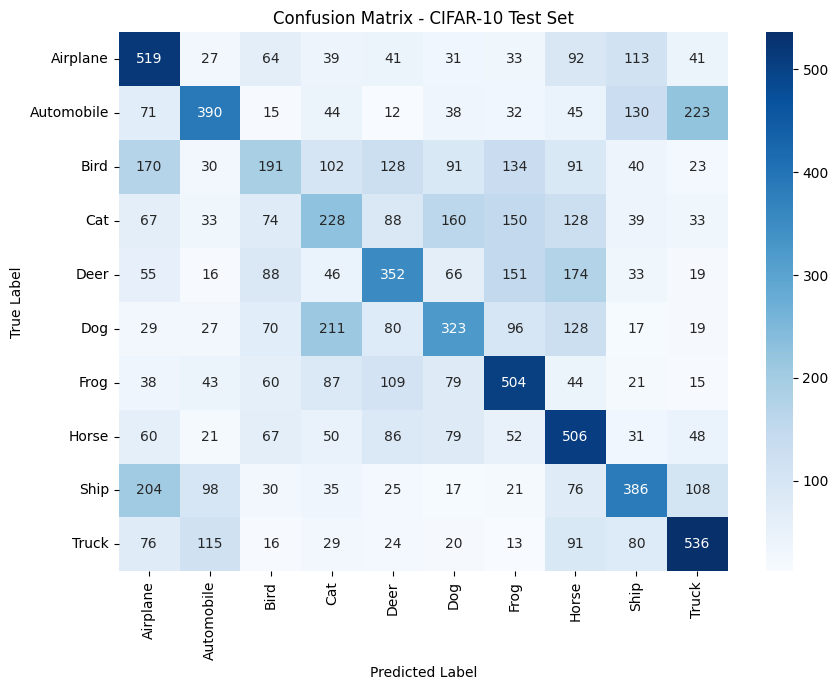


Saved 'classification_report.txt' and 'confusion_matrix.png'.


In [5]:
"""
Task 5: Model Evaluation

Evaluate the trained (fine-tuned) model using:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- Classification Report

NOTE: Continues from Task 4 - assumes `model`, `x_test`, `y_test` already
exist in the session. If running standalone, reloads the saved fine-tuned
model and re-prepares the test data.
"""

import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

NUM_CLASSES = 10
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# ---------------------------------------------------------------
# Reload model/data if running standalone (skip if continuing from Task 4)
# ---------------------------------------------------------------
try:
    model
    x_test
    y_test
except NameError:
    model = tf.keras.models.load_model("cifar10_finetuned_model.keras")
    (_, _), (x_test, y_test_raw) = tf.keras.datasets.cifar10.load_data()
    x_test = x_test.astype("float32") / 255.0
    y_test = to_categorical(y_test_raw, NUM_CLASSES)
else:
    # y_test may already be one-hot from earlier tasks
    pass

# ---------------------------------------------------------------
# 1. Get predictions
# ---------------------------------------------------------------
y_pred_probs = model.predict(x_test, batch_size=32)
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert true labels back to class indices (in case they're one-hot)
if y_test.ndim > 1 and y_test.shape[1] == NUM_CLASSES:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test.flatten()

# ---------------------------------------------------------------
# 2. Accuracy, Precision, Recall, F1-score
# ---------------------------------------------------------------
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print("===== Overall Evaluation Metrics =====")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}  (weighted avg)")
print(f"Recall:    {recall:.4f}  (weighted avg)")
print(f"F1-score:  {f1:.4f}  (weighted avg)")

# ---------------------------------------------------------------
# 3. Classification Report (per-class precision/recall/F1)
# ---------------------------------------------------------------
print("\n===== Classification Report =====")
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

with open("classification_report.txt", "w") as f:
    f.write(report)

# ---------------------------------------------------------------
# 4. Confusion Matrix
# ---------------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - CIFAR-10 Test Set")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

print("\nSaved 'classification_report.txt' and 'confusion_matrix.png'.")


Run: baseline
Config: {'learning_rate': 0.001, 'batch_size': 32, 'epochs': 3, 'optimizer': 'Adam', 'dense_units': 128, 'frozen_layers': 'All'}


/tmp/ipykernel_478/1408322869.py:75: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=INPUT_SHAPE)


Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 29ms/step - accuracy: 0.3022 - loss: 1.9255 - val_accuracy: 0.3216 - val_loss: 1.8599
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 28ms/step - accuracy: 0.3364 - loss: 1.8284 - val_accuracy: 0.3417 - val_loss: 1.8258
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.3498 - loss: 1.7894 - val_accuracy: 0.3441 - val_loss: 1.8053

Run: learning_rate = 0.0001
Config: {'learning_rate': 0.0001, 'batch_size': 32, 'epochs': 3, 'optimizer': 'Adam', 'dense_units': 128, 'frozen_layers': 'All'}
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 29ms/step - accuracy: 0.2476 - loss: 2.1373 - val_accuracy: 0.2864 - val_loss: 2.0144
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.2970 - loss: 1.9665 - val_accuracy: 0.3022 - val_loss: 1.9407
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.3103 - loss: 1.9179 - val_accuracy: 0.3083 - val_loss: 1.9134

Run: batch_size = 16
Config: {'learning_rate': 0.001, 

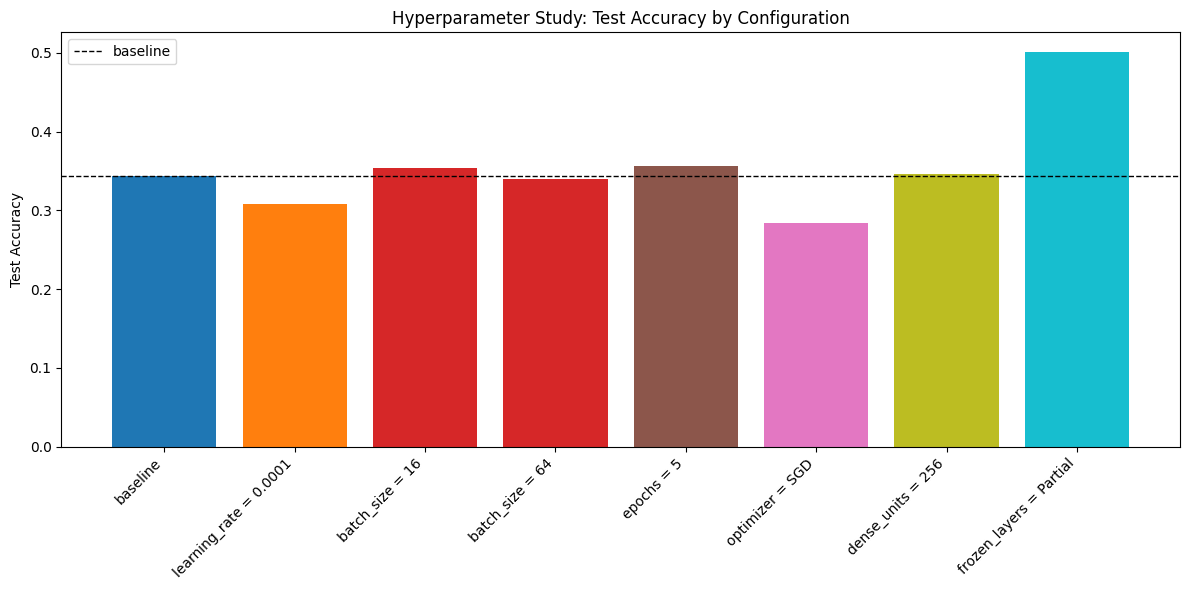


Saved 'hyperparameter_study_results.csv' and 'hyperparameter_study_chart.png'.


In [6]:
"""
Task 16: Hyperparameter Study

Compares model performance across different hyperparameter settings:
- Learning Rate : 0.001, 0.0001
- Batch Size    : 16, 32, 64
- Epochs        : 10, 20
- Optimizer     : Adam, SGD
- Dense Units   : 128, 256
- Frozen Layers : All, Partial (last conv block unfrozen)

APPROACH: A full grid search over all combinations would be
2 x 3 x 2 x 2 x 2 x 2 = 96 training runs, which is impractical for most
setups. Instead this uses a One-Factor-At-a-Time (OFAT) study:
- Define a baseline configuration.
- Vary ONE hyperparameter at a time across its listed values,
  keeping all others fixed at the baseline.
- Record test accuracy/loss for each run.

This isolates the effect of each hyperparameter individually and needs
only (2+3+2+2+2+2) - 5 duplicate baseline runs = ~11 training runs
instead of 96. If you need the full grid search instead, see the note
at the bottom of this script.
"""

import itertools
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

NUM_CLASSES = 10
INPUT_SHAPE = (32, 32, 3)

# ---------------------------------------------------------------
# Data (loaded once, reused for every run)
# ---------------------------------------------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
y_train = to_categorical(y_train, NUM_CLASSES)
y_test = to_categorical(y_test, NUM_CLASSES)

# ---------------------------------------------------------------
# Baseline configuration
# ---------------------------------------------------------------
BASELINE = {
    "learning_rate": 0.001,
    "batch_size": 32,
    "epochs": 3,
    "optimizer": "Adam",
    "dense_units": 128,
    "frozen_layers": "All",
}

# Hyperparameter search space (name -> list of values to try)
# NOTE: epochs reduced to 3/5 (instead of the assignment's 10/20) purely to
# make the sweep fast to iterate on. Bump back up to [10, 20] for your final
# reported numbers once the pipeline is verified to work end-to-end.
SEARCH_SPACE = {
    "learning_rate": [0.001, 0.0001],
    "batch_size": [16, 32, 64],
    "epochs": [3, 5],
    "optimizer": ["Adam", "SGD"],
    "dense_units": [128, 256],
    "frozen_layers": ["All", "Partial"],
}


def build_model(dense_units, frozen_layers):
    base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=INPUT_SHAPE)

    if frozen_layers == "All":
        base_model.trainable = False
    else:  # "Partial" -> unfreeze last conv block (block_16 onward)
        base_model.trainable = True
        unfreeze = False
        for layer in base_model.layers:
            if "block_16" in layer.name:
                unfreeze = True
            layer.trainable = unfreeze

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(dense_units, activation="relu"),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ])
    return model


def get_optimizer(name, lr):
    if name == "Adam":
        return Adam(learning_rate=lr)
    elif name == "SGD":
        return SGD(learning_rate=lr, momentum=0.9)
    else:
        raise ValueError(f"Unknown optimizer: {name}")


def run_experiment(config, run_name):
    print(f"\n{'='*60}\nRun: {run_name}\nConfig: {config}\n{'='*60}")

    model = build_model(config["dense_units"], config["frozen_layers"])
    model.compile(
        optimizer=get_optimizer(config["optimizer"], config["learning_rate"]),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        x_train, y_train,
        batch_size=config["batch_size"],
        epochs=config["epochs"],
        validation_data=(x_test, y_test),
        verbose=1
    )

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    return {
        "run_name": run_name,
        "varied_param": run_name.split("=")[0].strip() if "=" in run_name else "baseline",
        "test_accuracy": test_acc,
        "test_loss": test_loss,
        "final_train_accuracy": history.history["accuracy"][-1],
        **config
    }


# ---------------------------------------------------------------
# Run baseline + OFAT sweeps
# ---------------------------------------------------------------
results = []

# Baseline run
results.append(run_experiment(BASELINE, "baseline"))

# Vary each hyperparameter, one at a time, holding others at baseline
for param, values in SEARCH_SPACE.items():
    for val in values:
        if val == BASELINE[param]:
            continue  # already covered by the baseline run
        config = dict(BASELINE)
        config[param] = val
        run_name = f"{param} = {val}"
        results.append(run_experiment(config, run_name))

# ---------------------------------------------------------------
# Results table
# ---------------------------------------------------------------
df = pd.DataFrame(results)
df = df[["run_name", "varied_param", "test_accuracy", "test_loss",
         "final_train_accuracy", "learning_rate", "batch_size",
         "epochs", "optimizer", "dense_units", "frozen_layers"]]
df.to_csv("hyperparameter_study_results.csv", index=False)

print("\n\n===== Hyperparameter Study Results =====")
print(df.to_string(index=False))

# ---------------------------------------------------------------
# Plot: test accuracy per run, grouped by which parameter was varied
# ---------------------------------------------------------------
plt.figure(figsize=(12, 6))
colors = plt.cm.tab10(np.linspace(0, 1, df["varied_param"].nunique()))
color_map = dict(zip(df["varied_param"].unique(), colors))
bar_colors = [color_map[p] for p in df["varied_param"]]

plt.bar(df["run_name"], df["test_accuracy"], color=bar_colors)
plt.axhline(df.loc[df["run_name"] == "baseline", "test_accuracy"].values[0],
            color="black", linestyle="--", linewidth=1, label="baseline")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test Accuracy")
plt.title("Hyperparameter Study: Test Accuracy by Configuration")
plt.legend()
plt.tight_layout()
plt.savefig("hyperparameter_study_chart.png", dpi=150)
plt.show()

print("\nSaved 'hyperparameter_study_results.csv' and 'hyperparameter_study_chart.png'.")

# ---------------------------------------------------------------
# NOTE: Full grid search (all 96 combinations) instead of OFAT
# ---------------------------------------------------------------
# Uncomment below to run every combination instead of one-at-a-time.
# WARNING: this trains 96 separate models - very time/compute intensive.
#
# keys = list(SEARCH_SPACE.keys())
# all_results = []
# for combo in itertools.product(*SEARCH_SPACE.values()):
#     config = dict(zip(keys, combo))
#     run_name = ", ".join(f"{k}={v}" for k, v in config.items())
#     all_results.append(run_experiment(config, run_name))
# grid_df = pd.DataFrame(all_results)
# grid_df.to_csv("hyperparameter_full_grid_results.csv", index=False)